# Model Testing Notebook

Imports

In [11]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score

Import data sample and split

In [21]:
train_sample_df, val_sample_df = image_dataset_from_directory(
    "wikiart_sample",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 2656 files belonging to 23 classes.
Using 2125 files for training.
Using 531 files for validation.


Import all data and split

In [22]:
train_df, val_df = image_dataset_from_directory(
    "wikiart_datasets",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


In [4]:
input_shape= (512,512,3)

In [6]:
First_model = Sequential(
    layers= [Input(input_shape),
             Rescaling(scale= 1./255),

             #Primeira Convolutional
             Conv2D(filters=30, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Segunda Convolutional
             Conv2D(filters=60, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Terceira Convolutional
             Conv2D(filters=120, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),
              
            #Flatten e Dense layer
            Flatten(),

            #Primeiro Dense layer com mais neurons
            Dense(40, activation="relu"),

            #Second dense layer
            Dense(23, activation="softmax")
            
               ])


In [8]:
First_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 60)   │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 60)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 120)  │        64,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 461280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │    18,451,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           943 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,534,203 (70.70 MB)

 Trainable params: 18,534,203 (70.70 MB)

 Non-trainable params: 0 (0.00 B)

Próxima parte temos de definar o que vai no Comlile, ou seja:

- A loss function
- O optimizer 
- As metrics

In [12]:
optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

# metrics
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [15]:
#Dar compile com o que acabamos de definir
First_model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [16]:
#Defenir número de epoches e batch size

epochs = 10
batchsize= 64

In [ ]:
#Dar fit do modelo de sample

First_model.fit(
    train_sample_df,
    validation_data=val_sample_df,
    epochs=epochs
)                            #Não é preciso meter batch_size porque já foi especificado quando importarmos os dados

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.0692 - auc: 0.5416 - f1_score: 0.0229 - loss: 3.1570 - val_accuracy: 0.0395 - val_auc: 0.5385 - val_f1_score: 0.0150 - val_loss: 3.1414
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.0795 - auc: 0.5751 - f1_score: 0.0288 - loss: 3.0977 - val_accuracy: 0.1036 - val_auc: 0.5871 - val_f1_score: 0.0256 - val_loss: 3.0853
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.1021 - auc: 0.5980 - f1_score: 0.0362 - loss: 3.0681 - val_accuracy: 0.0603 - val_auc: 0.5467 - val_f1_score: 0.0183 - val_loss: 3.3935
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1172 - auc: 0.6211 - f1_score: 0.0318 - loss: 3.0340 - val_accuracy: 0.1168 - val_auc: 0.6152 - val_f1_score: 0.0325 - val_loss: 3.0541
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1529 - auc: 0.6492 - f1_score: 0.0405 - loss: 2.9779 - val_accuracy: 0.0942 - val_auc: 0.6362 - val_f1_score: 0.0251 - val_loss: 3.032

Dar plot das metrics

In [20]:
print(First_model.history.keys()) 

AttributeError: 'History' object has no attribute 'keys'

TypeError: 'History' object is not subscriptable

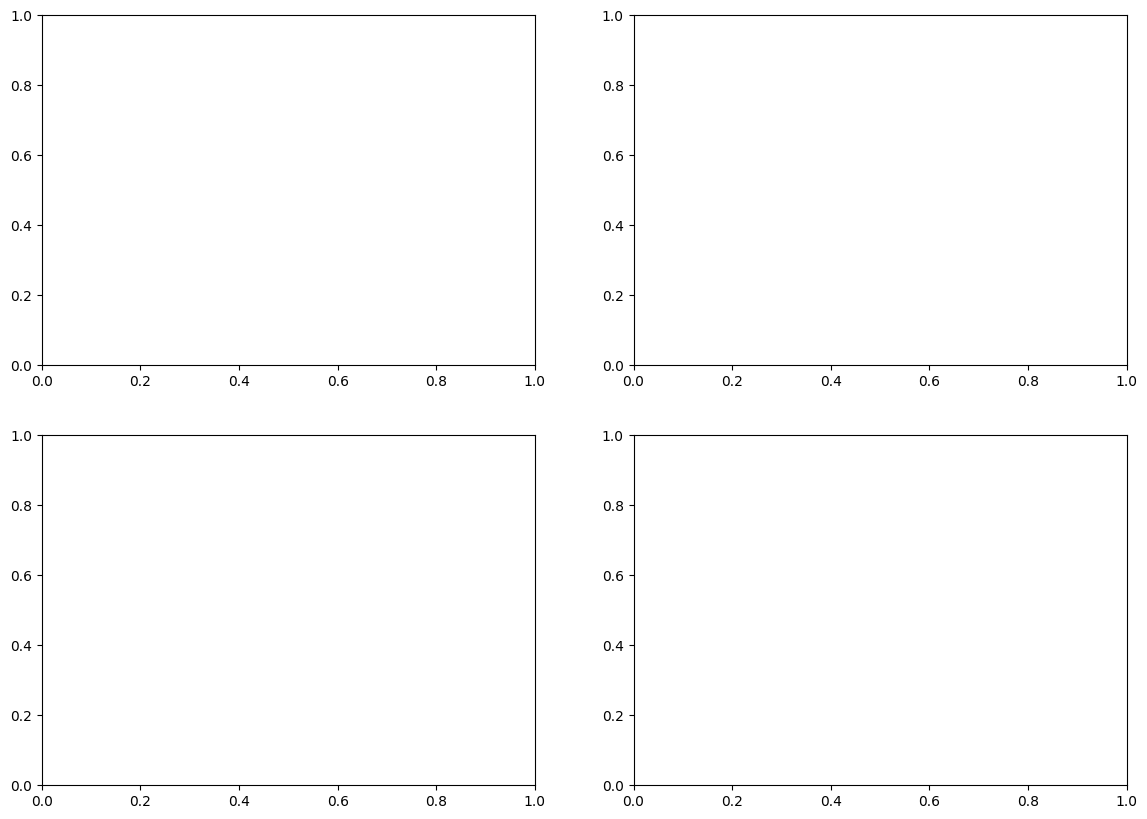

In [19]:
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

plot_history(First_model)

Primeiro modelo com todos os dados

In [23]:
AD_first_model =First_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)         

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.2254 - auc: 0.7462 - f1_score: 0.1151 - loss: 2.7100 - val_accuracy: 0.2095 - val_auc: 0.7509 - val_f1_score: 0.1265 - val_loss: 2.7042
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.2567 - auc: 0.7833 - f1_score: 0.1663 - loss: 2.5736 - val_accuracy: 0.2549 - val_auc: 0.7760 - val_f1_score: 0.1660 - val_loss: 2.6005
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.2823 - auc: 0.8083 - f1_score: 0.2029 - loss: 2.4657 - val_accuracy: 0.2178 - val_auc: 0.7829 - val_f1_score: 0.1435 - val_loss: 2.6188
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.3033 - auc: 0.8273 - f1_score: 0.2314 - loss: 2.3753 - val_accuracy: 0.2676 - val_auc: 0.8070 - val_f1_score: 0.1998 - val_loss: 2.4915
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.3343 - auc: 0.8433 - f1_score: 0.2688 - loss: 2.2821 - val_accuracy: 0.2702 - val_auc: 0.7997 - val_f1_score: 0.2084 - va

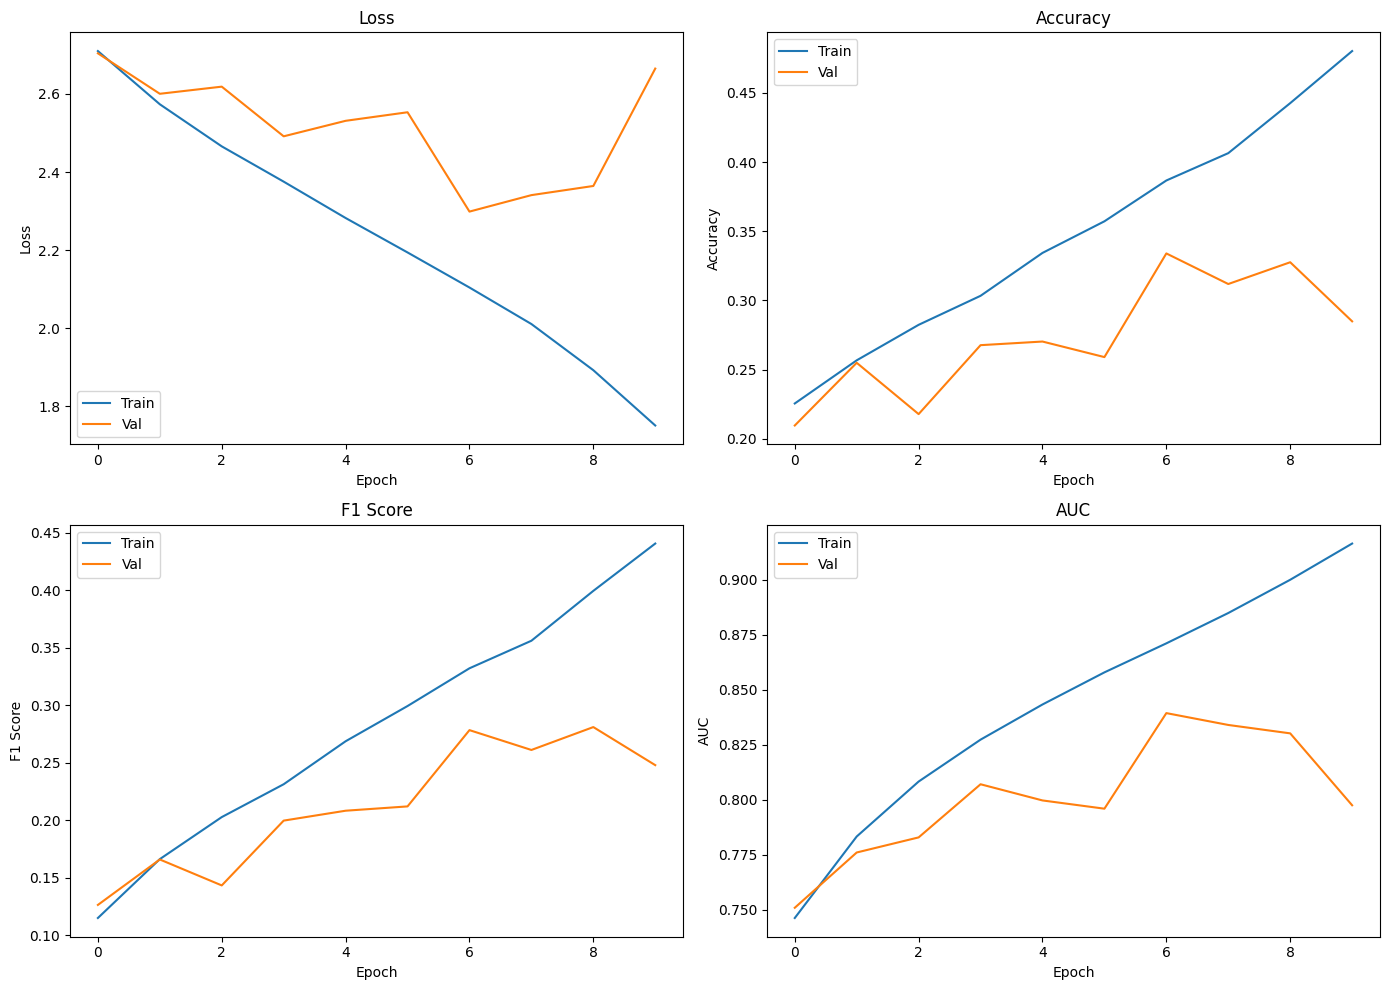

In [ ]:
plot_history(AD_first_model)